<a href="https://colab.research.google.com/github/chrisnelsonlab/BMEG4623/blob/master/3_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://brand.uark.edu/_resources/images/UA_Logo_Horizontal.jpg width="400" height="96">

####BMEG 4623 - Tranposrt phenomenon in biomedical engineering
####For more information, check out the Nelson lab for Therapeutic Genome Engineering (https://nelsonlab.uark.edu/)

For image credits, see the linked URL

#1. Introduction

The goal for today is to develop a differential equation toolbox for solving the heat equation in cartesian coordinates, 1D, with or without heat generation, at steady state

# Plan


We want to solve the heat equation for the scenario below

<img src=https://raw.githubusercontent.com/chrisnelsonlab/BMEG4623/refs/heads/master/Images/HeatTransport.png>



We could have any combination of boundary conditions.



*   The object will have a dimmension of L in meters
*   Input temperature will be in Kelvin
*   Input heat generation will be in W/m^3
*   Input thermal conductivity in W/mK
*   Input Heat Flux in W/m^2
*   Input heat transfer coef as W/m^2K










Temperature distribution T(x):
100.0⋅x + 293.15

Heat flux distribution qx(x):
-60.0000000000000

T at x=L/2: 298.15
0.05
100.0*x + 293.15


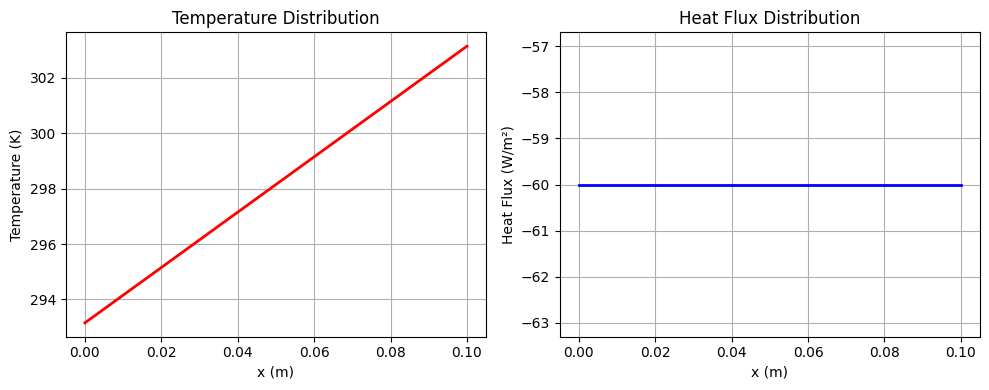

In [14]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def steady_heat_1D(L, k, q_gen=0,
                   BC_left=('Dirichlet', 300),
                   BC_right=('Neumann', 0)):
    """
    Solve 1D steady-state heat conduction with optional generation.

    Governing equation: d²T/dx² + q_gen/k = 0

    Parameters
    ----------
    L : float
        Thickness of domain (m)
    k : float
        Thermal conductivity (W/m·K)
    q_gen : float
        Volumetric heat generation (W/m³), default=0
    BC_left : tuple
        ('Dirichlet', T0) or ('Neumann', q0) or ('Robin', (h, T_inf))
        at x=0
    BC_right : tuple
        Same, applied at x=L
    """

    # define variables
    x = sp.Symbol('x')
    C1, C2 = sp.symbols('C1 C2')

    # general solution: T(x) = -(q_gen/(2k)) x² + C1*x + C2
    T = -(q_gen/(2*k))*x**2 + C1*x + C2

    # first derivative for flux
    dTdx = sp.diff(T, x)
    qx = -k*dTdx

    # apply boundary conditions
    equations = []

    # left BC
    if BC_left[0] == 'Dirichlet':
        equations.append(T.subs(x, 0) - BC_left[1])
    elif BC_left[0] == 'Neumann':  # flux into domain at x=0
        equations.append(qx.subs(x, 0) - BC_left[1])
    elif BC_left[0] == 'Robin':  # convection: -k dT/dx = h (T(0)-T_inf)
        h, T_inf = BC_left[1]
        equations.append(qx.subs(x, 0) - h*(T.subs(x, 0) - T_inf))

    # right BC
    if BC_right[0] == 'Dirichlet':
        equations.append(T.subs(x, L) - BC_right[1])
    elif BC_right[0] == 'Neumann':
        equations.append(qx.subs(x, L) - BC_right[1])
    elif BC_right[0] == 'Robin':
        h, T_inf = BC_right[1]
        equations.append(qx.subs(x, L) - h*(T.subs(x, L) - T_inf))

    # solve for C1, C2
    sol = sp.solve(equations, (C1, C2))
    T = T.subs(sol)
    qx = qx.subs(sol)

    return sp.simplify(T), sp.simplify(qx)

def plot_solution(T, qx, L, n_points=100):
    """Plot temperature and heat flux distributions."""
    x = sp.Symbol('x')
    f_T = sp.lambdify(x, T, 'numpy')
    f_qx = sp.lambdify(x, qx, 'numpy')

    xs = np.linspace(0, L, n_points)

    Ts = f_T(xs)
    qs = f_qx(xs)

    # ensure outputs are arrays with the same shape as xs
    Ts = np.array(Ts, dtype=float).reshape(-1)
    if np.isscalar(qs):  # if flux is constant
        qs = np.full_like(xs, float(qs))
    else:
        qs = np.array(qs, dtype=float).reshape(-1)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    ax[0].plot(xs, Ts, 'r-', linewidth=2)
    ax[0].set_xlabel('x (m)')
    ax[0].set_ylabel('Temperature (K)')
    ax[0].set_title('Temperature Distribution')
    ax[0].grid(True)

    ax[1].plot(xs, qs, 'b-', linewidth=2)
    ax[1].set_xlabel('x (m)')
    ax[1].set_ylabel('Heat Flux (W/m²)')
    ax[1].set_title('Heat Flux Distribution')
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
# Example usage
if __name__ == "__main__":
    # tissue slab, 1 cm thick, k=0.5 W/mK, q_gen=1000 W/m³
    # left side fixed T=310 K, right side insulated


    L=0.1
    T, qx = steady_heat_1D(
        L,
        k=0.6,
        q_gen=0,
        BC_left=('Dirichlet', 293.15),
        BC_right=('Neumann', -60)
    )

    print("Temperature distribution T(x):")
    sp.pprint(T)

    print("\nHeat flux distribution qx(x):")
    sp.pprint(qx)

    # Example: evaluate at center
    print("\nT at x=L/2:", float(T.subs({'x':L/2})))

    print(L/2)
    print(T)

    plot_solution(T, qx, L)

# Analysis

Consider the code above. This was generated by AI.

*   First, work through it step by step and consier how it works
*   Do you see any issues with the code?
*   Are there any conditions that the equations break down (combination of boundary conditions?)
